# Take-Home Exam B: The Damped Driven Harmonic Oscillator

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

A mass on a spring with damping and a sinusoidal driving force obeys:

$$m\ddot{x} + b\dot{x} + kx = F_0 \cos(\omega_d t)$$

Dividing by $m$ and defining $\gamma = b/(2m)$ and $\omega_0 = \sqrt{k/m}$:

$$\ddot{x} + 2\gamma\dot{x} + \omega_0^2 x = \frac{F_0}{m}\cos(\omega_d t)$$

We use $\omega_0 = 1$, $F_0/m = 1$ throughout.

**Handling time-dependent forcing.** Our `myode.py` solvers only pass `y` to `diffeq` — they don't pass the current time $t$. To handle a force that depends explicitly on $t$, **augment the state vector** with time as an extra variable:

$$\mathbf{y} = [x,\; v,\; t_{\rm now}], \qquad \dot{\mathbf{y}} = [v,\; a,\; 1]$$

where $a = -2\gamma v - \omega_0^2 x + \cos(\omega_d \cdot t_{\rm now})$ and the last component $1$ simply means $dt_{\rm now}/dt = 1$.

**Analytical steady-state amplitude** (after transients decay):

$$A(\omega_d) = \frac{F_0/m}{\sqrt{(\omega_0^2 - \omega_d^2)^2 + (2\gamma\omega_d)^2}}$$


In [1]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Overwriting myode.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import myode

omega0 = 1.0   # natural frequency
F_over_m = 1.0 # driving amplitude / mass

# TODO: implement diffeq for the DDHO with augmented state.
# y = [x, v, t_now]
# ydot = [v, acceleration, 1]
# The acceleration depends on gamma and omega_d,
# which you will set as global variables before each simulation.

gamma = 0.1    # damping coefficient (will be changed per part)
omega_d = 1.0  # driving frequency   (will be changed per part)

def diffeq(y):
    x, v, t_now = y
    a = -2*gamma*v - omega0**2*x + F_over_m*np.cos(omega_d*t_now)
    return np.array([v, a, 1.0])

def analytical_amplitude(gam, wd):
    return F_over_m / np.sqrt((omega0**2 - wd**2)**2 + (2*gam*wd)**2)
    # Steady-state amplitude from the analytical formula.

## Part 1 — Free Oscillation (No Driving Force)

Set $F_0/m = 0$ (driving off) and $\gamma = 0.1$. Starting from $x_0 = 1$, $v_0 = 0$, simulate for $t = 0$ to $60$.

1. Plot $x(t)$ vs time.
2. The envelope of the oscillation should decay as $e^{-\gamma t}$. Overlay this envelope (both $+e^{-\gamma t}$ and $-e^{-\gamma t}$) on your plot.
3. Measure the oscillation period numerically and compare to $T = 2\pi/\omega_d'$ where $\omega_d' = \sqrt{\omega_0^2 - \gamma^2}$ is the damped frequency.

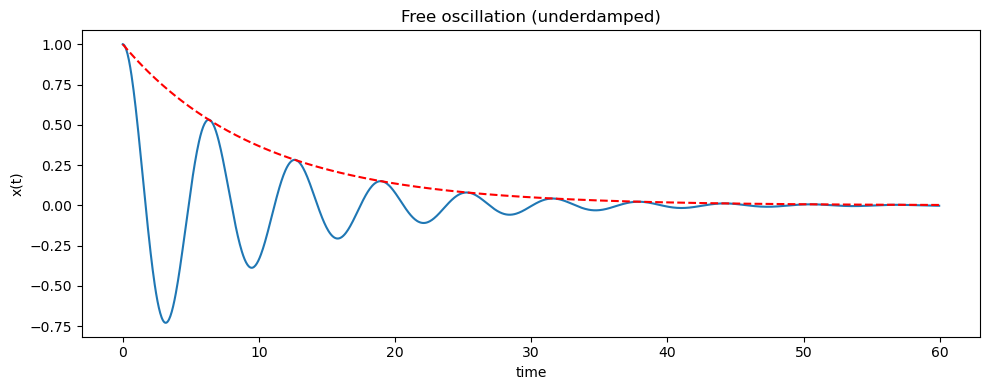

Theoretical damped period: 6.3148
Measured period: 6.3000


In [5]:
# Part 1: free oscillation
gamma = 0.1
omega_d = 0.0   # no driving
dt = 0.05
t_range = np.arange(0, 60, dt)

# Temporarily set F_over_m = 0 by redefining diffeq, OR
# set F_over_m = 0 globally above and rerun this cell.
# Hint: it's cleaner to redefine diffeq_free here without the forcing term.

def diffeq_free(y):
    x, v, t_now = y
    a = -2*gamma*v - omega0**2 * x
    return np.array([v, a, 1.0])

y0 = np.array([1.0, 0.0, 0.0])   # [x0, v0, t0]
# TODO: run RK2 loop, collect x and t
xs, ts_out = [], []
y = y0.copy()
for t in t_range:
    xs.append(y[0])
    ts_out.append(y[2])
    y = myode.move_RK2(diffeq_free, y, dt)


fig, ax = plt.subplots(figsize=(10, 4))
# TODO: plot x(t)
ax.plot(ts_out, xs, label='x(t)')
ax.plot(ts_out, np.exp(-gamma*np.array(ts_out)), 'r--')
ax.set_xlabel('time'); ax.set_ylabel('x(t)')
ax.set_title('Free oscillation (underdamped)')
plt.tight_layout(); plt.show()

# TODO: measure the period numerically

peaks = []
for i in range(1, len(xs)-1):
    if xs[i] > xs[i-1] and xs[i] > xs[i+1]:
        peaks.append(ts_out[i])

measured_period = peaks[1] - peaks[0]

omega_damped_theory = np.sqrt(omega0**2 - gamma**2)
print(f'Theoretical damped period: {2*np.pi/omega_damped_theory:.4f}')
# print(f'Measured period: ...')
print(f'Measured period: {measured_period:.4f}')

**Written response (Part 1):** Does the decay follow the expected envelope? Report the measured period and compare to the theoretical value. What would happen to the oscillation if $\gamma > \omega_0$?

It does follow an expected evnelope. The measured period is 6.3 and the theoretical period is 6.3148. If gamme is greater than omega then it would be no oscillations.

## Part 2 — Driven Steady State

Now turn on the driving force. Use $\gamma = 0.2$ and $\omega_d = 0.8$ (slightly off resonance). Start from rest: $x_0 = 0$, $v_0 = 0$. Simulate for $t = 0$ to $100$.

1. Plot $x(t)$. You should see transient behavior at early times that gives way to steady oscillation.
2. Measure the steady-state amplitude (average of peak values for $t > 80$).
3. Compute the analytical amplitude $A(\omega_d)$ and compare.
4. On a second plot, zoom in on $t = 85$ to $100$ and overlay the analytical steady state $A\cos(\omega_d t - \phi)$, where $\tan\phi = 2\gamma\omega_d/(\omega_0^2 - \omega_d^2)$.

Analytical amplitude: 2.0761


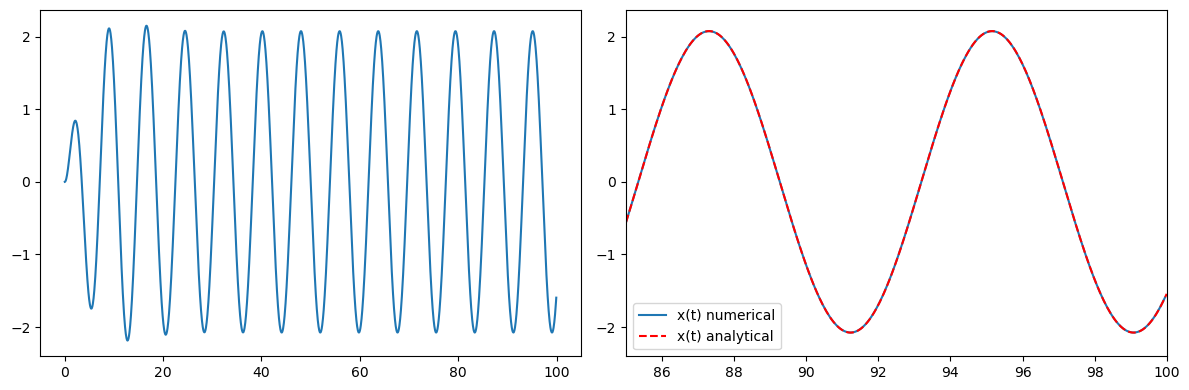

In [22]:
gamma   = 0.2
omega_d = 0.8
F_over_m = 1.0  # restore driving
dt = 0.05
t_range = np.arange(0, 100, dt)

y0 = np.array([0.0, 0.0, 0.0])
xs, ts_out = [], []
# TODO: run RK2 and collect x, t
y = y0.copy()
for t in t_range:
    xs.append(y[0])
    ts_out.append(y[2])
    y = myode.move_RK2(diffeq, y, dt)

# Analytical steady state
A_theory = analytical_amplitude(gamma, omega_d)
phi = np.arctan2(2*gamma*omega_d, omega0**2 - omega_d**2)
print(f'Analytical amplitude: {A_theory:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0]: full x(t) trace
# axes[1]: zoom on t>85, with analytical overlay
t_fine = np.linspace(85, 100, 500)



axes[0].plot(ts_out, xs)



x_analytical = A_theory * np.cos(omega_d * t_fine - phi)

axes[1].plot(ts_out, xs, label = 'x(t) numerical')
axes[1].set_xlim(85,100)


axes[1].plot(t_fine, x_analytical, 'r--', label = "x(t) analytical")
axes[1].legend()
plt.tight_layout(); plt.show()

# TODO: measure steady-state amplitude and print comparison

**Written response (Part 2):** How long does the transient last (roughly how many oscillation periods)? How does your measured amplitude compare to the analytical value? What sets the duration of the transient — $\gamma$ or $\omega_d$?

## Part 3 — Resonance Curve

The steady-state amplitude depends strongly on driving frequency. Use $\gamma = 0.1$ and scan $\omega_d$ from $0.1$ to $2.0$ in steps of $0.05$.

For each $\omega_d$:
- Simulate long enough for transients to decay (you need to decide how long)
- Measure the steady-state amplitude

1. Plot measured amplitude vs $\omega_d$. Overlay the analytical curve.
2. Identify the resonant frequency from your plot and compare to $\omega_0 = 1$.
3. Repeat for $\gamma = 0.3$ and $\gamma = 0.5$ on the same plot.

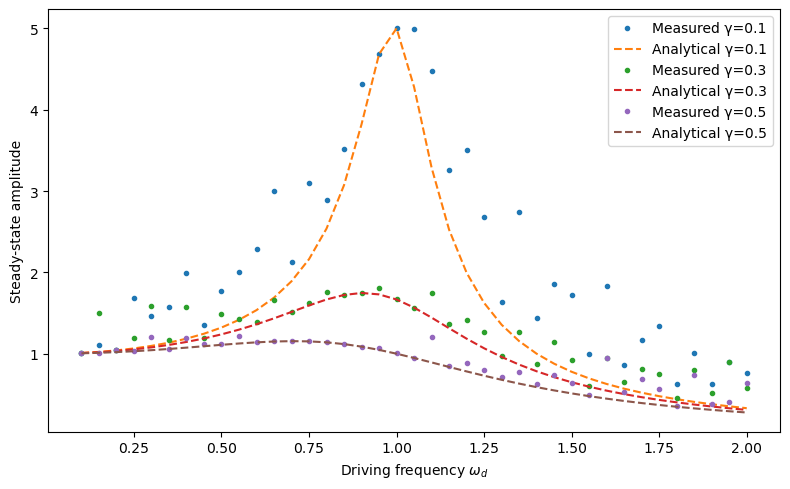

In [5]:
gammas = [0.1, 0.3, 0.5]
omega_d_vals = np.arange(0.1, 2.05, 0.05)
dt = 0.05

fig, ax = plt.subplots(figsize=(8, 5))

for gamma in gammas:
    amplitudes = []
    for wd in omega_d_vals:
        omega_d = wd
        # TODO: simulate and measure steady-state amplitude
        # Hint: run for t_total, then average abs(x) over the last few periods
        t_total = 200   # choose long enough for transients to die out
        t_range = np.arange(0, t_total, dt)
        y0 = np.array([0.0, 0.0, 0.0])
        # ... run loop ...
        xs = []
        ts = []

        for t in t_range:
            xs.append(y[0])
            ts.append(y[2])
            y = myode.move_RK2(diffeq, y, dt)

        xs = np.array(xs)
        ts = np.array(ts)
        mask = ts > 0.8 * t_total
        amp = np.max(np.abs(xs[mask]))  # replace with measured amplitude
        amplitudes.append(amp)

    # Plot measured and analytical
    A_analytical = [analytical_amplitude(gamma, wd) for wd in omega_d_vals]
    ax.plot(omega_d_vals, amplitudes, 'o', markersize=3, label=f'Measured γ={gamma}')
    ax.plot(omega_d_vals, A_analytical, '--', label=f'Analytical γ={gamma}')

ax.set_xlabel('Driving frequency $\omega_d$')
ax.set_ylabel('Steady-state amplitude')
ax.legend(); plt.tight_layout(); plt.show()

**Written response (Part 3):** Where is the peak amplitude for each $\gamma$ value? How does increasing $\gamma$ affect the height and width of the resonance peak? Define the quality factor $Q = \omega_0 / (2\gamma)$ and relate it to what you observe.

## Part 4 — Numerical Error Near Resonance

Near resonance, the oscillation amplitude is large and changes rapidly, making it a demanding test of a numerical integrator.

Use $\gamma = 0.1$, $\omega_d = 1.0$ (exactly at resonance). Simulate from $t=0$ to $t=80$ using three timesteps: $dt = 0.5,\; 0.1,\; 0.02$.

1. Plot $x(t)$ for all three on the same graph.
2. Compute the steady-state amplitude for each and compare to the analytical value.
3. Compute the fractional error: $(A_{\rm measured} - A_{\rm theory})/A_{\rm theory}$.

Analytical resonance amplitude: 5.00
A_measured = 5.372, fractional error = 0.0744
A_measured = 5.004, fractional error = 0.0009
A_measured = 4.998, fractional error = -0.0004


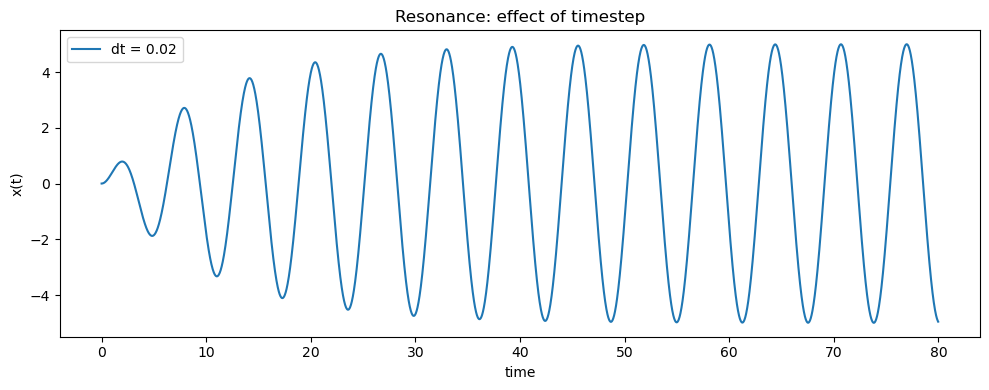

In [6]:
gamma = 0.1
omega_d = 1.0   # resonance
F_over_m = 1.0
A_theory = analytical_amplitude(gamma, omega_d)
print(f'Analytical resonance amplitude: {A_theory:.2f}')

fig, ax = plt.subplots(figsize=(10, 4))

for dt in [0.5, 0.1, 0.02]:
    t_range = np.arange(0, 80, dt)
    y0 = np.array([0.0, 0.0, 0.0])
    # TODO: run RK2 and collect x, t
    y = y0.copy()
    xs = []
    ts = []

    for t in t_range:
        xs.append(y[0])
        ts.append(y[2])
        y = myode.move_RK2(diffeq, y, dt)
    xs = np.array(xs)
    ts = np.array(ts)
    # TODO: measure steady-state amplitude (use last 10% of simulation)
    mask = ts > 0.9 * ts[-1]
    A_measured = np.max(np.abs(xs[mask]))
    # TODO: plot and print fractional error
    frac_error = (A_measured - A_theory) / A_theory
    print(f'A_measured = {A_measured:.3f}, fractional error = {frac_error:.4f}')
    
ax.plot(ts, xs, label=f'dt = {dt}')
ax.set_xlabel('time'); ax.set_ylabel('x(t)')
ax.set_title('Resonance: effect of timestep')
ax.legend(); plt.tight_layout(); plt.show()

**Written response (Part 4):** How large must $dt$ be before the numerical solution becomes unreliable near resonance? Give a physical argument for why large-amplitude, rapidly changing oscillations are harder to integrate accurately.

## Part 5 — Open-Ended Exploration

**A: Overdamped and critically damped regimes.** With no driving force ($F_0 = 0$), explore $\gamma = 0.5$ (underdamped), $\gamma = 1.0$ (critically damped), and $\gamma = 2.0$ (overdamped). Starting from $x_0 = 1$, $v_0 = 0$, plot all three on the same graph. Explain the qualitative difference in each case and identify which regime returns to equilibrium fastest.

**B: Amplitude growth at resonance.** For a lightly damped system ($\gamma = 0.01$), drive at exact resonance $\omega_d = 1$. Plot the amplitude envelope over many periods. How does the amplitude grow with time before reaching steady state? (It should grow linearly at early times — verify this numerically.)

**C: Nonlinear spring.** Replace the spring force $-\omega_0^2 x$ with $-\omega_0^2 x - \epsilon x^3$ ($\epsilon = 0.5$). This is the Duffing oscillator. With driving at $\omega_d = 1$, does the resonance peak shift? Plot the resonance curve for both the linear and nonlinear cases.

In [7]:
# Part 5 work
